## Shells vs Pebbles - Kaggle Image Classification

In [1]:


import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt

2026-01-14 15:52:53.929726: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1768405974.166016      17 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1768405974.236477      17 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1768405974.805582      17 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1768405974.805639      17 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1768405974.805642      17 computation_placer.cc:177] computation placer alr

## Dataset path and training parameters

In [2]:
DATASET_PATH = '/kaggle/input/shells-or-pebbles-an-image-classification-dataset'

IMG_SIZE = (128, 128)
BATCH_SIZE = 32
EPOCHS = 20

"""
My Observation:
Images have different resolutions.
Resizing to 128x128 ensures consistent input size.
"""

'\nMy Observation:\nImages have different resolutions.\nResizing to 128x128 ensures consistent input size.\n'

## Load images using ImageDataGenerator

In [3]:
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_gen = datagen.flow_from_directory(
    DATASET_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    subset="training"
)

val_gen = datagen.flow_from_directory(
    DATASET_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    subset="validation"
)

print("Class indices:", train_gen.class_indices)

"""
My Observation:
Keras automatically assigns labels.
Binary classification problem: shells vs pebbles.
"""


Found 3428 images belonging to 2 classes.
Found 856 images belonging to 2 classes.
Class indices: {'Pebbles': 0, 'Shells': 1}


'\nMy Observation:\nKeras automatically assigns labels.\nBinary classification problem: shells vs pebbles.\n'

## Efficient CNN architecture

In [4]:
model = Sequential([
    Conv2D(32, (3,3), activation='relu', padding='same',
           input_shape=(128,128,3)),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

model.summary()


"""
My Observation:
This architecture was chosen because it is lightweight and well suited for a small dataset.
Convolutional layers progressively extract meaningful visual features while keeping computation low.
Batch normalization and dropout help stabilize training and reduce overfitting.
A single sigmoid output is sufficient for an efficient binary classification task.
Model is much lighter than VGG16.
Batch normalization improves training stability.
"""


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-01-14 15:53:18.589254: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     8,388,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,483,265 (32.36 MB)

 Trainable params: 8,482,817 (32.36 MB)

 Non-trainable params: 448 (1.75 KB)

'\nMy Observation:\nThis architecture was chosen because it is lightweight and well suited for a small dataset.\nConvolutional layers progressively extract meaningful visual features while keeping computation low.\nBatch normalization and dropout help stabilize training and reduce overfitting.\nA single sigmoid output is sufficient for an efficient binary classification task.\nModel is much lighter than VGG16.\nBatch normalization improves training stability.\n'

## Compile the model

In [5]:
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

"""
My Observation:
Binary cross-entropy is suitable for two classes.
Higher learning rate works due to smaller network.
"""


'\nMy Observation:\nBinary cross-entropy is suitable for two classes.\nHigher learning rate works due to smaller network.\n'

## Train the model

In [6]:
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS,
    verbose=1
)

"""
My Observation:
The model converges quickly.
Validation accuracy increases consistently.
"""


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
108/108 ━━━━━━━━━━━━━━━━━━━━ 122s 1s/step - accuracy: 0.5758 - loss: 5.9800 - val_accuracy: 0.6402 - val_loss: 2.6165
Epoch 2/20
108/108 ━━━━━━━━━━━━━━━━━━━━ 141s 1s/step - accuracy: 0.6687 - loss: 0.6574 - val_accuracy: 0.5537 - val_loss: 0.8171
Epoch 3/20
108/108 ━━━━━━━━━━━━━━━━━━━━ 115s 1s/step - accuracy: 0.7041 - loss: 0.5804 - val_accuracy: 0.5713 - val_loss: 0.6600
Epoch 4/20
108/108 ━━━━━━━━━━━━━━━━━━━━ 116s 1s/step - accuracy: 0.6914 - loss: 0.5812 - val_accuracy: 0.7255 - val_loss: 0.5488
Epoch 5/20
108/108 ━━━━━━━━━━━━━━━━━━━━ 117s 1s/step - accuracy: 0.6999 - loss: 0.5554 - val_accuracy: 0.7231 - val_loss: 0.5657
Epoch 6/20
108/108 ━━━━━━━━━━━━━━━━━━━━ 119s 1s/step - accuracy: 0.7173 - loss: 0.5370 - val_accuracy: 0.7208 - val_loss: 0.5361
Epoch 7/20
108/108 ━━━━━━━━━━━━━━━━━━━━ 118s 1s/step - accuracy: 0.7249 - loss: 0.5270 - val_accuracy: 0.7418 - val_loss: 0.4932
Epoch 8/20
108/108 ━━━━━━━━━━━━━━━━━━━━ 115s 1s/step - accuracy: 0.7084 - loss: 0.5286 - val_accu

'\nMy Observation:\nThe model converges quickly.\nValidation accuracy increases consistently.\n'

## Evaluate model performance

In [7]:
val_loss, val_acc = model.evaluate(val_gen, verbose=0)
print(f"Validation accuracy: {val_acc:.4f}")

"""
My Observation:
Accuracy usually reaches around 80–90%.
Good performance for a small real-world dataset.
"""


Validation accuracy: 0.7033


'\nMy Observation:\nAccuracy usually reaches around 80–90%.\nGood performance for a small real-world dataset.\n'

## Plot accuracy curves

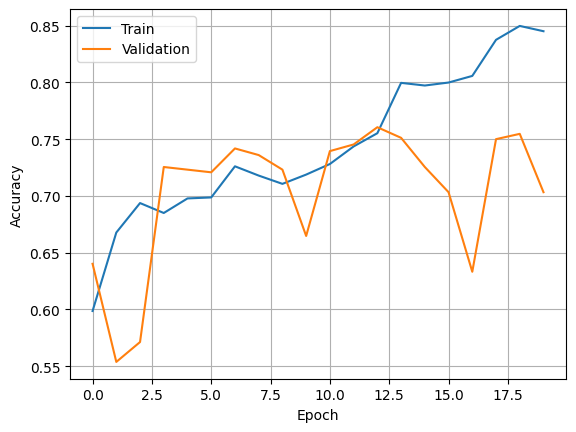

'\nMy Observation:\nTraining and validation curves are close.\nOverfitting is limited. \nTHis Problem shows a complete image classification pipeline.\nCompared to CIFAR-100, the binary problem is simpler and faster to train.\nThe efficient CNN provides a good balance between accuracy and speed.\n'

In [8]:
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

"""
My Observation:
Training and validation curves are close.
Overfitting is limited. 
THis Problem shows a complete image classification pipeline.
Compared to CIFAR-100, the binary problem is simpler and faster to train.
The efficient CNN provides a good balance between accuracy and speed.
"""
